# IMT 573 - Final Examination


Points: 100

Name: Austin Cornia

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

*Austin Cornia*

11/26/2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [94]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [95]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [96]:
 affairs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
dtypes: float64(9)
memory usage: 447.7 KB


In [97]:
affairs.isnull().sum()

rate_marriage      0
age                0
yrs_married        0
children           0
religious          0
educ               0
occupation         0
occupation_husb    0
affairs            0
dtype: int64

In [98]:
affairs.describe()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
count,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000
mean,4.109645,29.082862,9.009425,1.396874,2.426170,14.209865,3.424128,3.850141,0.705374
std,0.961430,6.847882,7.280120,1.433471,0.878369,2.178003,0.942399,1.346435,2.203374
min,1.000000,17.500000,0.500000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000
25%,4.000000,22.000000,2.500000,0.000000,2.000000,12.000000,3.000000,3.000000,0.000000
50%,4.000000,27.000000,6.000000,1.000000,2.000000,14.000000,3.000000,4.000000,0.000000
75%,5.000000,32.000000,16.500000,2.000000,3.000000,16.000000,4.000000,5.000000,0.484848
max,5.000000,42.000000,23.000000,5.500000,4.000000,20.000000,6.000000,6.000000,57.599991


**We can see that the dataset has 6366 participants ranging from 17 and a half years to 42 years. The number of years married for the participants is 9 years, with as low as half a year of marriage up to a maximum of 23 years. The average number of children for this dataset is 1.4 kids. I don't have any ethical concerns, as long as the names (which are not included) do not get traced back to them. Also, I would like people not to use this dataset to make assumptions about the entire population.**

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [99]:
# Copying affairs dataframe to new affairs_copy
affairs_copy = affairs.copy()

# Create a new column Had_affair for anyone spending more than 0 time in an affair
affairs_copy['Had_affair'] = (affairs_copy['affairs'] > 0).astype(int)

# Dropping the affairs time column from the df
affairs_copy = affairs_copy.drop(columns = ['affairs'])

affairs_copy.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,Had_affair
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,1


**The advantages of modeling something like this are that it can be used to fit a model easily, as we are looking for a binary outcome of 1 or 0. The disadvantages are that we are losing meaning by making it this simple, as someone who has had 1 affair is treated the same as someone who has had 5 affairs. The simplicity makes it easier to run tests, but it makes our analysis harder to understand in real-life terms.**

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

**Using code from problem set 8 for setting up logistics regression model**

In [100]:
# Convert categorical columns to category dtype to prevent them from being treated as continuous numeric variables
categorical_columns = ['religious', 'educ', 'occupation', 'occupation_husb']
for column in categorical_columns:
    affairs_copy[column] = affairs_copy[column].astype('category')

affairs_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   rate_marriage    6366 non-null   float64 
 1   age              6366 non-null   float64 
 2   yrs_married      6366 non-null   float64 
 3   children         6366 non-null   float64 
 4   religious        6366 non-null   category
 5   educ             6366 non-null   category
 6   occupation       6366 non-null   category
 7   occupation_husb  6366 non-null   category
 8   Had_affair       6366 non-null   int64   
dtypes: category(4), float64(4), int64(1)
memory usage: 274.5 KB


In [101]:
# Creating dummy variables for categorical predictor variables
X = pd.get_dummies(affairs_copy.drop(columns = ['Had_affair']), drop_first = True)
y = affairs_copy['Had_affair']

# Force numeric dtype for logistic regression
X = X.astype(float)

In [102]:
X

,rate_marriage,age,yrs_married,children,religious_2.0,religious_3.0,religious_4.0,educ_12.0,educ_14.0,educ_16.0,...,occupation_2.0,occupation_3.0,occupation_4.0,occupation_5.0,occupation_6.0,occupation_husb_2.0,occupation_husb_3.0,occupation_husb_4.0,occupation_husb_5.0,occupation_husb_6.0
0,3.0,32.0,9.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3.0,27.0,13.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,4.0,22.0,2.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4.0,37.0,16.5,4.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5.0,27.0,9.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6362,4.0,32.0,13.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6363,5.0,22.0,2.5,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6364,5.0,32.0,6.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [103]:
X = sm.add_constant(X)

# Logistic regression
logit_mod = sm.Logit(y, X)
logit_res = logit_mod.fit()
print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.541447
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             Had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6343
Method:                           MLE   Df Model:                           22
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.1388
Time:                        06:29:45   Log-Likelihood:                -3446.9
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.712e-221
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.3468      0.610      3.850      0.000       1.152       3.542
ra

**When it comes to statistical significance, we have multiple variables under an assumed 0.05 alpha level, meaning significance. Those variables are the age of the participants, years married, marriage ratings, Religion categories 2 - 4 (mildly to fairly), and occupation of the wife 5 and 6 (business and advanced degrees). We see that higher ratings of marriages have a larger negative slope, which means the higher the rating of the marriage is, the less chance for an affair to occur. We see the same effect in religion, as the more religious someone is, the less chance of an affair occurring as well. Advanced degree and business occupations for the wife also seem to indicate a higher chance of an affair, as both have positive slopes. Years married has a positive slope, granted it is small, meaning the longer you are married, the higher the chance for an affair to occur. Lastly, age has a very small negative slope when it comes to predicting whether an affair will occur or not.**

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

**Using this resource: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html**

In [104]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

In [105]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [106]:
log_reg = LogisticRegression(max_iter = 5000)

sfs = SequentialFeatureSelector(estimator = log_reg, n_features_to_select = 5, direction = 'forward', cv = 10, scoring = 'accuracy')

sfs.fit(X_scaled, y)
selected_features = X.columns[sfs.get_support()]

X_selected = sm.add_constant(X_scaled[selected_features])
final_model = sm.Logit(y, X_selected).fit()
print(final_model.summary())

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/pyt

Optimization terminated successfully.
         Current function value: 0.551620
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             Had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6360
Method:                           MLE   Df Model:                            5
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.1227
Time:                        06:29:46   Log-Likelihood:                -3511.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.147e-210
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.8522      0.030    -28.488      0.000      -0.911      -0.794
rate_marriage    

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/

**Yes, the stepwise logistic regression includes far fewer predictors than our full logistic regression model. 11 predictor variables were used in the stepwise model compared to 25 in the full one. The variables that were kept were age, yrs_married, children, rate_marriage, religious_4.0, educ_12.0, educ_14.0, educ_16.0, occupation_3.0, occupation_5.0, occupation_6.0, and occupation_husb_4.0**

(e) Interpret the model parameters using the model from part (d).

**Age has a strong negative relationship, as older women are less likely to report an affair. When it comes to years of marriage, we can see that the more years married, the slightly increased odds of an affair occurring. Women who rate their marriage higher lower the odds of an affair occurring. Being more religious is one of the strongest predictive factors, with the most religious women being much less likely to report an affair. Among occupations, occupation categories 3, 5, and 6 show significantly higher odds of having an affair. Education level and the husband’s occupation were not significant predictors. Overall, the model suggests that relationship satisfaction, age of the relationship, and occupational context are the main factors associated with affairs.**

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

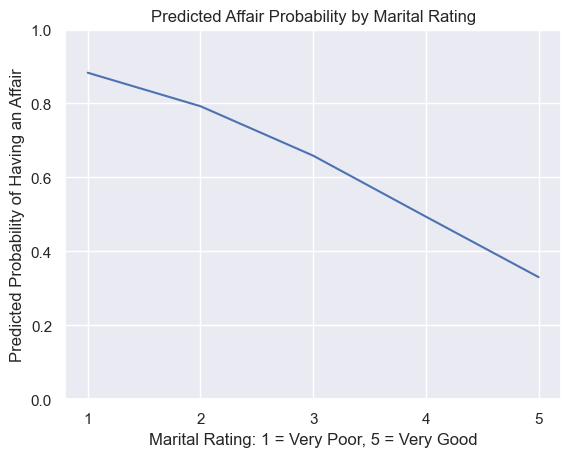

   rate_marriage  pred_prob
0              1   0.883235
1              2   0.792602
2              3   0.658795
3              4   0.493794
4              5   0.330135


In [107]:
# 27 is always the best seed
np.random.seed(27)

numeric_cols = ['age', 'yrs_married', 'children']
category_cols = ['religious', 'educ', 'occupation', 'occupation_husb']

num_means = affairs[numeric_cols].mean()
cat_modes = affairs[category_cols].mode().iloc[0]

artificial_raw = pd.DataFrame({'rate_marriage': np.random.randint(1, 6, size = 500), 'age': num_means['age'], 'yrs_married': num_means['yrs_married'],
    'children': num_means['children'],
    'religious': cat_modes['religious'],
    'educ': cat_modes['educ'],
    'occupation': cat_modes['occupation'],
    'occupation_husb': cat_modes['occupation_husb']
})

# Ensure datatypes are correct
for column in category_cols:
    artificial_raw[column] = artificial_raw[column].astype('category')

# Get dummy values for X_artificial
X_artificial = pd.get_dummies(artificial_raw, drop_first = True).astype(float)

# Add constant, make sure to add has_constant, so it explicity adds a new constant column
X_artificial = sm.add_constant(X_artificial, has_constant = 'add')
X_artificial_selected = X_artificial.reindex(columns = X_selected.columns, fill_value = 0)

# Find the predicted probabilies
artificial_raw['pred_prob'] = final_model.predict(X_artificial_selected)

plot_df = (artificial_raw.groupby('rate_marriage', observed = True)['pred_prob'].mean().reset_index())

sns.lineplot(data = plot_df, x = 'rate_marriage', y = 'pred_prob')
plt.xlabel('Marital Rating: 1 = Very Poor, 5 = Very Good')
plt.ylabel('Predicted Probability of Having an Affair')
plt.title('Predicted Affair Probability by Marital Rating')
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 1)
plt.show()

print(plot_df)

**We can see that, holding all other variables constant, the predicted probability of having an affair decreases steadily as marital rating increases. At the highest marital rating of 5, the model predicts only a 16.9% chance of an affair.**

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

**I have concerns about the use of this data. Modeling these behaviors raises concerns for me about how someone could abuse the results. They could use it to target specific demographics. I also have major concerns if somehow this data gets connected back to the individual who provided it. Ideally, this is all anonymous, but it could potentially happen. Lastly is if we publish this data, we need to make sure we don't reinforce stereotypes. As people might interpret this as, "well, religious people never have affairs and thus make better marriage partners"**

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [108]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

In [109]:
Hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

In [110]:
Hitters.isnull().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

#### Research Question

**Do homeruns or hits matter more for having a larger salary?**\
**Bias going in: I beleive that homerun hitters do make money on average based on my experience of watching baseball**

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

**First thing we need to clean up is the rows with NULL salary values, as that will interfere with out visuals. Other comments are that we have 322 entries, with most fields being 64 bit integers, with have 3 cateogrical variables wtih league, division and whether they are new to the league. Lastly one float value for salary.**

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

In [111]:
Hitters_copy = Hitters.copy()

# Drop NULL Salary rows
Hitters_copy = Hitters_copy.dropna(subset = ['Salary'])

Hitters_copy.isnull().sum()

AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

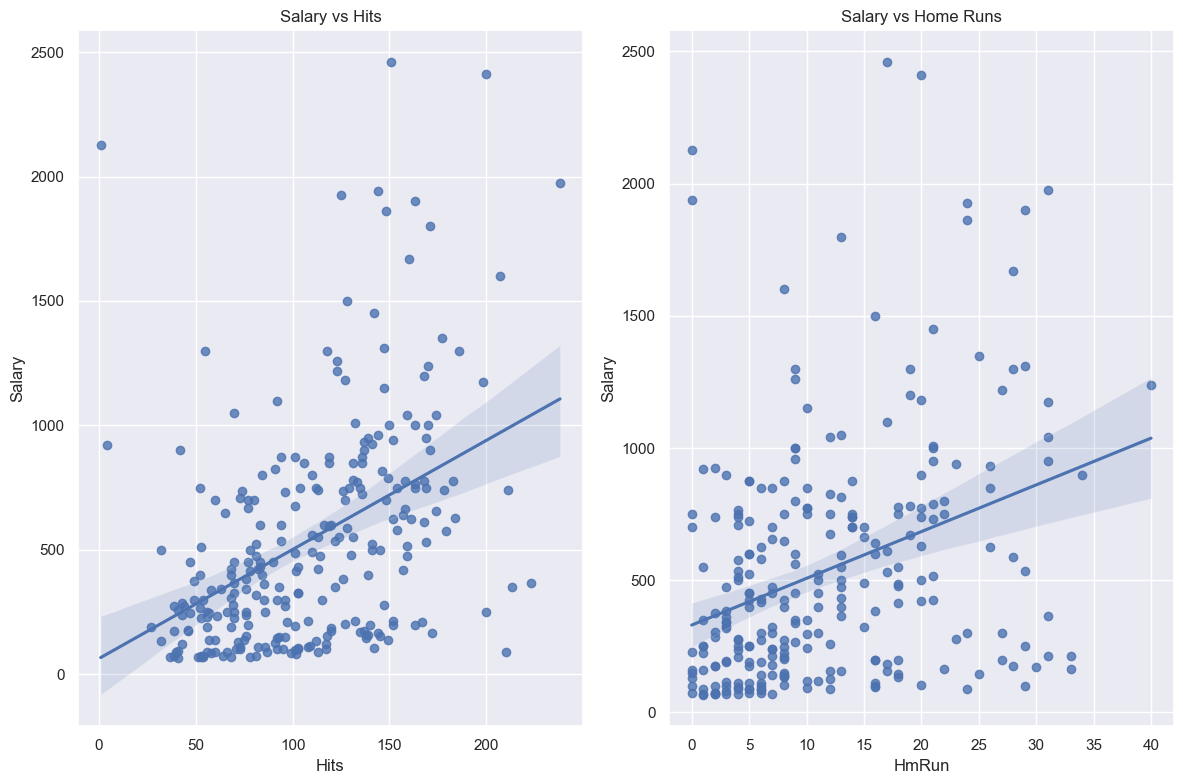

In [112]:
plt.figure(figsize = (12,8))

# Salary vs Hits figure
plt.subplot(1,2,1)
sns.regplot(x = 'Hits', y = 'Salary', data = Hitters_copy)
plt.title('Salary vs Hits')

# Salary vs Home Runs figure
plt.subplot(1,2,2)
sns.regplot(x = 'HmRun', y = 'Salary', data = Hitters_copy)
plt.title('Salary vs Home Runs')

plt.tight_layout()
plt.show()

**By plotting hits vs salary and homeruns vs salary on scatterplots we can see that in general getting more hits or homeruns means a higher salary (sort of obvious). Interestingly salary vs hits scatterplot shows a more upward slope compared to the homeruns plot indicating that players with more hits generally earn higher salaries. It's imperative to note however that cloud of points is widely scattered around the line, showing high variability for the hitter plot.**

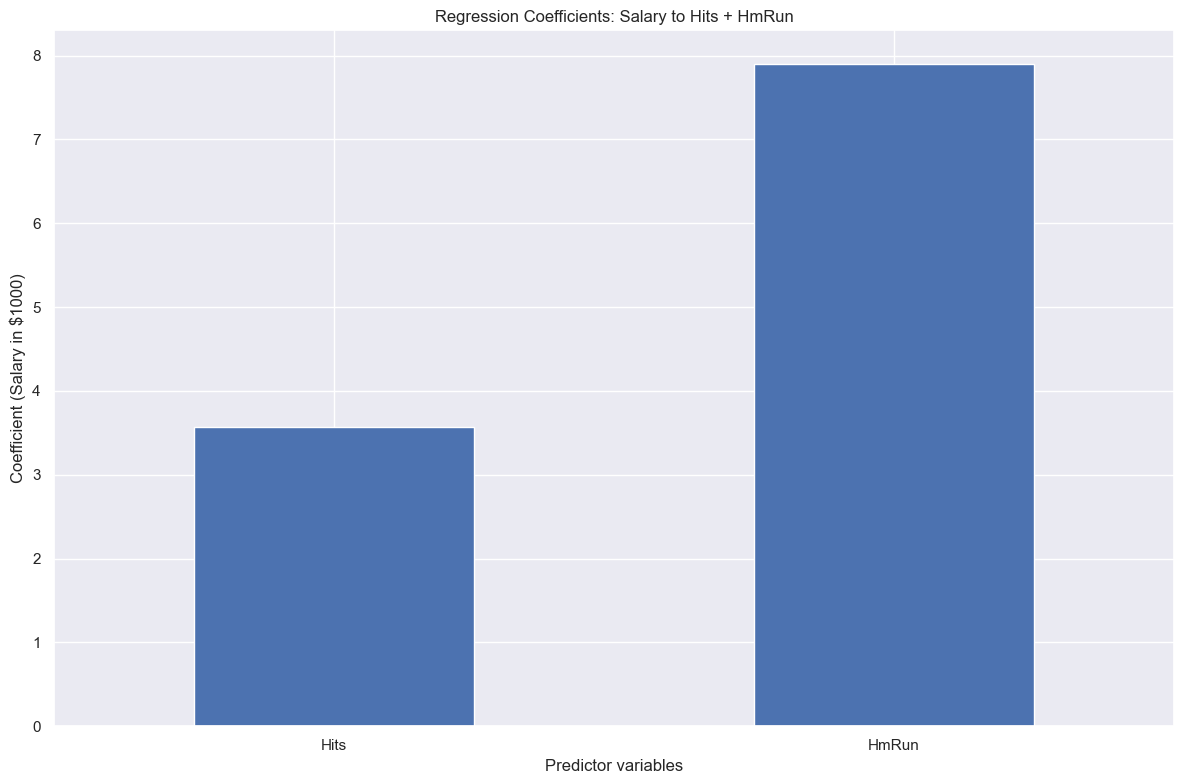

In [113]:
X = Hitters_copy[['HmRun', 'Hits']]
X = sm.add_constant(X)

y = Hitters_copy['Salary']

model = sm.OLS(y, X).fit()

coefs = model.params[['Hits', 'HmRun']]

plt.figure(figsize = (12,8))
coefs.plot(kind = 'bar')

plt.title('Regression Coefficients: Salary to Hits + HmRun')
plt.ylabel('Coefficient (Salary in $1000)')
plt.xlabel('Predictor variables')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

**Using a simple regression we can see that homeruns has a higher coefficent that hits by nearly double. This tells us that if we want to have a higher salary we want to focus on hitting more homeruns instead of getting more hits.**

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

**I was able to answer the questions, as we saw the two visuals actually showed different stories, and help show the issue with just using one visual to tell a story. If we use just the scatterplot we might think hits matter more than homeruns for higher salary, but doing regression analysis shows the oppossite. The problem with this question is that it's seeking an easy answer to a question that is hard to define in real life. Yes, homerun hitters from my experience and in this dataset tend to have higher salaries, but if you are hitting 40 homeruns with a 0.180 average (I'm talking about you Carlos Pena and Adam Dunn) you aren't going to valued that high. It's also important to note that the game of baseball has drastically changed, alot in thanks to money ball and sabermetrics increased usage, with OBP and batting average now being valued higher than back then.**

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [114]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

In [115]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [117]:
sns.set(style = 'whitegrid')

#### Categorical variables

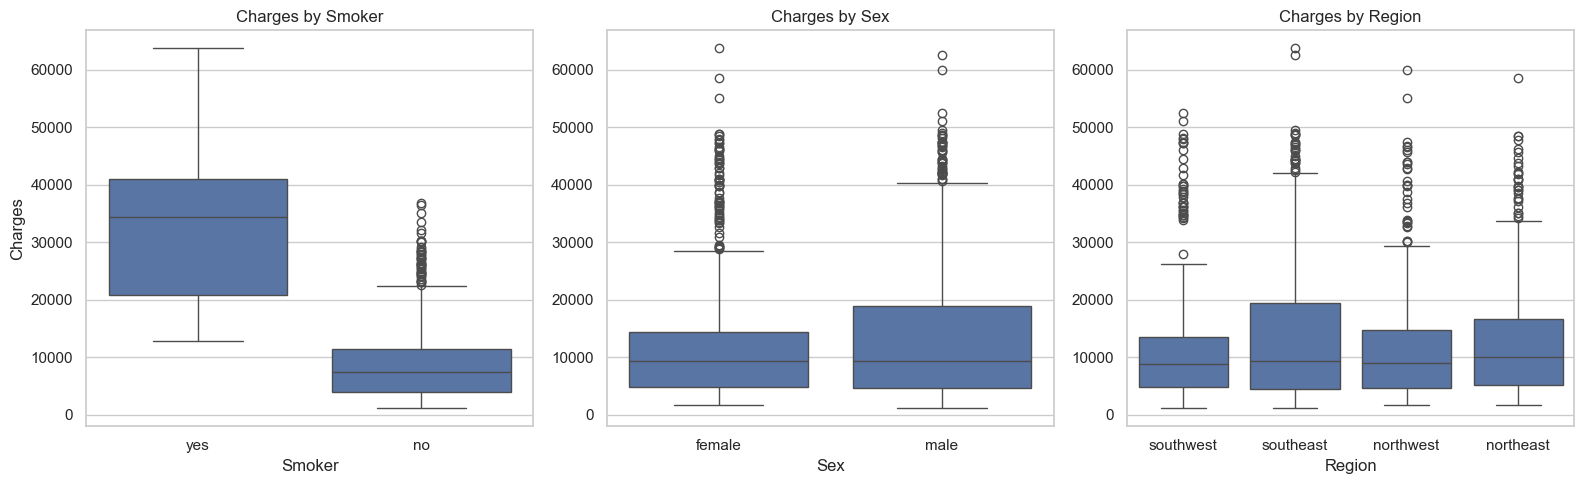

In [118]:
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

sns.boxplot(ax = axes[0], data = df, x = 'smoker', y = 'charges')
axes[0].set_title('Charges by Smoker')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges')

sns.boxplot(ax = axes[1], data = df, x = 'sex', y = 'charges')
axes[1].set_title('Charges by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('')
                  
sns.boxplot(ax = axes[2], data = df, x = 'region', y = 'charges')
axes[2].set_title('Charges by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

**The most obvious result here is from the charges by smoker box plot, there's a clear pattern where inviduals who smoke are charged more for insurance. Males slightly have a higher upper quartile in the box plot but overall sex has a minimal impact on medical charges and is likely not a meaningful predictor in the regression model. Region is also in a similar boat to sex, as only southeast region has a higher upper quartile compared to the rest.**

#### Numerical variables

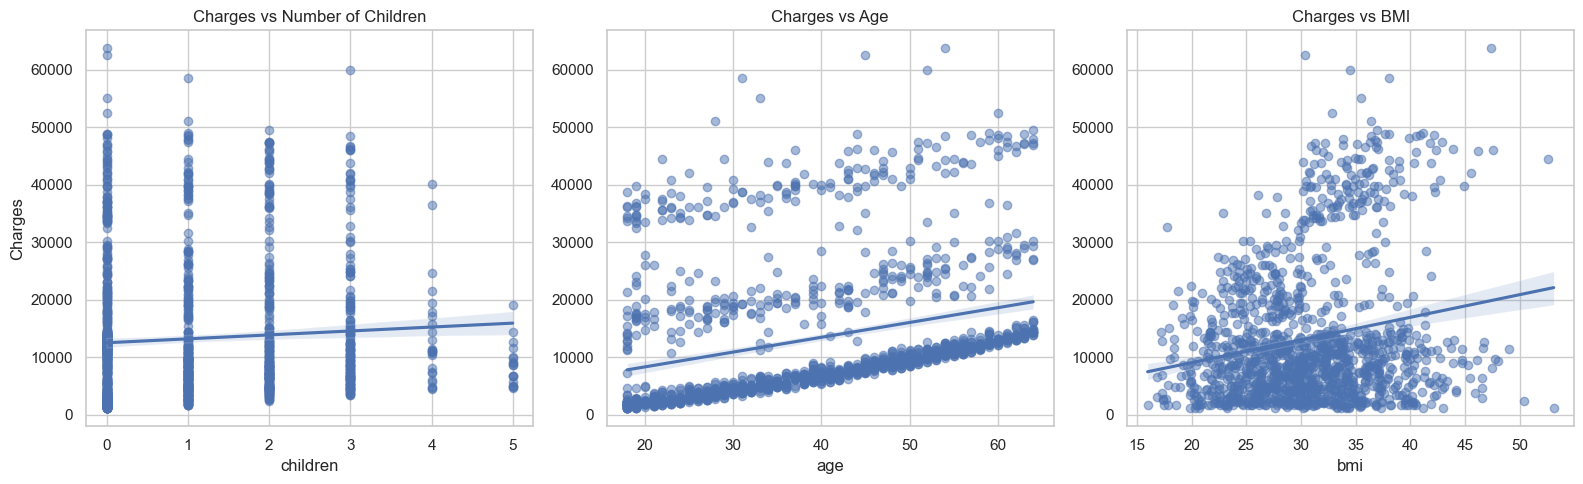

In [119]:
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

sns.regplot(ax = axes[0], data = df, x = 'children', y = 'charges', scatter_kws = {'alpha':0.5})
axes[0].set_title('Charges vs Number of Children')
axes[0].set_ylabel('Charges')

sns.regplot(ax = axes[1], data = df, x = 'age', y = 'charges', scatter_kws = {'alpha':0.5})
axes[1].set_title('Charges vs Age')
axes[1].set_ylabel('')

sns.regplot(ax = axes[2], data = df, x = 'bmi', y = 'charges', scatter_kws = {'alpha':0.5})
axes[2].set_title('Charges vs BMI')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

**The number of children has a weak relationship to the insurance cost, with no apparent patterns in the scatterplot. Age does show a huge cluster of data resembling a positive linear relationship to insurance charges. BMI shows a weak relationship to insurance charges as there's a ton of variance where teh data is located, not shocking because BMI averages are around 18 - 25.**

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [120]:
df_copy = df.copy()

# Convert categorical columns to category dtype to prevent them from being treated as continuous numeric variables
categorical_columns = ['sex', 'smoker', 'region']
for column in categorical_columns:
    df_copy[column] = df_copy[column].astype('category')

df_copy.info()

# Creating dummy variables for categorical predictor variables
X = pd.get_dummies(df_copy.drop(columns = ['charges']), drop_first = True)
y = df_copy['charges']

# Force numeric dtype for linear regression
X = X.astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int64   
 1   sex       1338 non-null   category
 2   bmi       1338 non-null   float64 
 3   children  1338 non-null   int64   
 4   smoker    1338 non-null   category
 5   region    1338 non-null   category
 6   charges   1338 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 46.3 KB


In [121]:
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,0.0,1.0,0.0,0.0,1.0
1,18.0,33.770,1.0,1.0,0.0,0.0,1.0,0.0
2,28.0,33.000,3.0,1.0,0.0,0.0,1.0,0.0
3,33.0,22.705,0.0,1.0,0.0,1.0,0.0,0.0
4,32.0,28.880,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,50.0,30.970,3.0,1.0,0.0,1.0,0.0,0.0
1334,18.0,31.920,0.0,0.0,0.0,0.0,0.0,0.0
1335,18.0,36.850,0.0,0.0,0.0,0.0,1.0,0.0
1336,21.0,25.800,0.0,0.0,0.0,0.0,0.0,1.0


In [122]:
X = sm.add_constant(X)

model_multi_reg = sm.OLS(y, X).fit()

model_multi_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        06:29:48   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819    -12.086      0.000   -1.39e+04      -1e+04
age                256.8564     11.899     21.587      0.000     233.514     280.199
bmi                339.1935     28.599     11.860      0.000     283.088     395.298
children           475.5005    137.804      3.451      0.001     205.163     745.838
sex_male          -131.3144    332.945     -0.394      0.693    -784.470     521.842
smoker_yes        2.385e+04    413.153     57.723      0.000     2.3e+04    2.47e+04
region_northwest  -352.9639    476.276     -0.741      0.459   -1287.298     581.370
region_southeast -1035.0220    478.692     -2.162      0.031   -1974.097     -95.947
region_southwest  -960.0510    477.933     -2.009      0.045   -1897.636     -22.466
==============================================================================
Omnibus:                      300.366   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              718.887
Skew:                           1.211   Prob(JB):                    7.86e-157
Kurtosis:                       5.651   Cond. No.                         311.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [123]:
# Dropping BMI from the matrix of X
X_no_BMI = X.drop(columns = ['bmi'])
X_no_BMI = sm.add_constant(X_no_BMI)

No_BMI_model = sm.OLS(y, X_no_BMI).fit()

r2_no_BMI = No_BMI_model.rsquared
r2_full_model = model_multi_reg.rsquared

print(r2_full_model)
print(r2_no_BMI)
print(r2_full_model - r2_no_BMI)

0.7509130345985207
0.7245494196468012
0.02636361495171946


**BMI explains approximately 2.64% (r2_full_model - r2_no_BMI) of the variance in medical charges after controlling for all other variables. Although BMI is statistically significant, its overall contribution to predicting medical costs is relatively small compared to other predictors.**

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

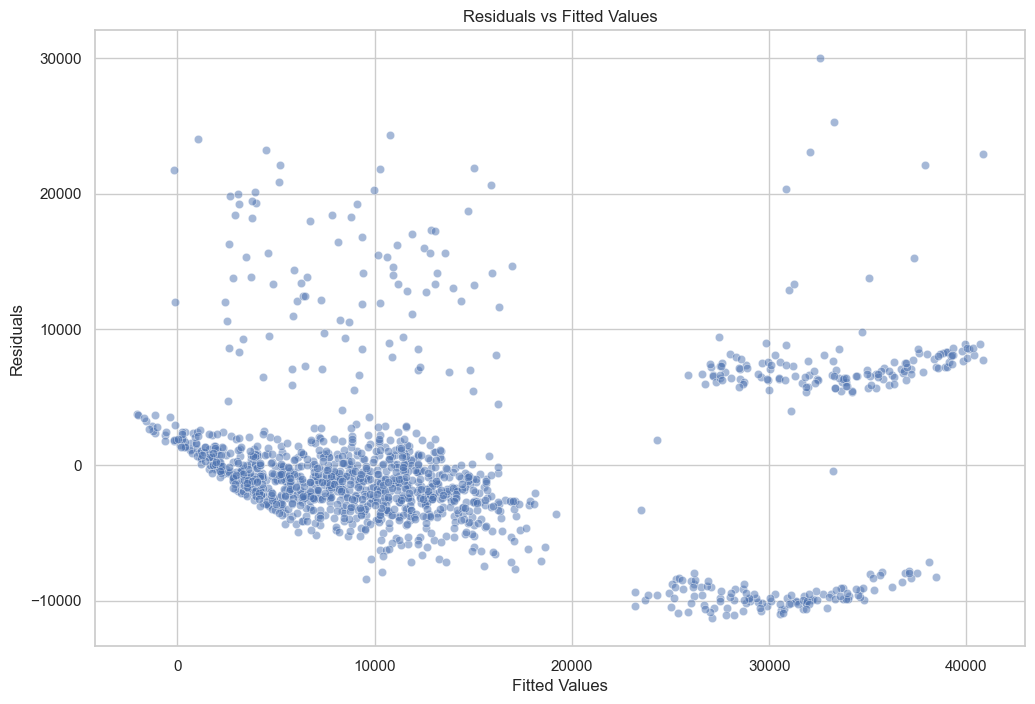

In [124]:
residuals = model_multi_reg.resid
fitted_values = model_multi_reg.fittedvalues

plt.figure(figsize = (12,8))
sns.scatterplot(x = fitted_values, y = residuals, alpha = 0.5)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.show()

**We see some issues with the fitted values and residuals. We have three sub-clusters around 0 to 10,000 and 30,000 to 40,000. This means we have non-constant variance, which goes against our assumption of constant variance. This might be due to how varied high-cost insured patients are. We also see how the clusters show a clear pattern, indicating that some of our predictor variables might not have a linear relationship to our response variable.**

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [125]:
sfs = SequentialFeatureSelector(estimator = LinearRegression(), n_features_to_select = 'auto', direction = 'backward', scoring = 'r2', cv = 10)

sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()]

X_sfs = sm.add_constant(X[selected_features])
sfs_model = sm.OLS(y, X_sfs).fit()
print(sfs_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     799.7
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        06:29:48   Log-Likelihood:                -13550.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1332   BIC:                         2.714e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.228e+04    948.666  

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevegon/Synolog

**Our model using sfs has produced a different model from our full model fit in part B. We remove several predictor variables and kept age, BMI, number of children, yes to being a smoker and southeast region. It removed specific predictor variables because they were not statistically significant and contributed little to predictive accuracy. We can see that the R^2 values are nearly identical between the models even though we removed 3 variables from the model**

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [126]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

In [127]:
# Add column names from https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin
colnames = [
    'Sample_code_number', 'Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape',
    'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 
    'Normal_nucleoli', 'Mitoses', 'Class'
]

cancer_df = pd.read_csv(location + dataframe, header = None, names = colnames)

cancer_df.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [128]:
cancer_df.shape

(699, 11)

In [129]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample_code_number           699 non-null    int64 
 1   Clump_thickness              699 non-null    int64 
 2   Uniformity_of_cell_size      699 non-null    int64 
 3   Uniformity_of_cell_shape     699 non-null    int64 
 4   Marginal_adhesion            699 non-null    int64 
 5   Single_epithelial_cell_size  699 non-null    int64 
 6   Bare_nuclei                  699 non-null    object
 7   Bland_chromatin              699 non-null    int64 
 8   Normal_nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


**699 entries of data, we have 11 columns, with most of them ebing 64 bit integers, and Bare_nuclei being an object data type (for some reason). The data describes 699 observations of breast cell samples, and the goal is to figure out whether the sample is malignant or benign**

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [130]:
cancer_df.isnull().sum()

Sample_code_number             0
Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

In [131]:
# find all unique values for Bare_nuclei
cancer_df['Bare_nuclei'].unique()[:]

array(['1', '10', '2', '4', '3', '9', '7', '?', '5', '8', '6'],
      dtype=object)

In [132]:
cancer_df_copy = cancer_df.copy()

In [133]:
# Replace all ? with NAN values
cancer_df_copy['Bare_nuclei'] = cancer_df_copy['Bare_nuclei'].replace('?', np.nan)
cancer_df_copy['Bare_nuclei'] = pd.to_numeric(cancer_df_copy['Bare_nuclei'])

In [134]:
cancer_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sample_code_number           699 non-null    int64  
 1   Clump_thickness              699 non-null    int64  
 2   Uniformity_of_cell_size      699 non-null    int64  
 3   Uniformity_of_cell_shape     699 non-null    int64  
 4   Marginal_adhesion            699 non-null    int64  
 5   Single_epithelial_cell_size  699 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              699 non-null    int64  
 8   Normal_nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
 10  Class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


In [135]:
cancer_df_copy.isnull().sum()

Sample_code_number              0
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [136]:
# Mapping Class from 2 and 4 to 0 and 1
cancer_df_copy['Class'] = cancer_df_copy['Class'].map({2: 0, 4: 1})
cancer_df_copy.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


**Important things we did to the dataset, we noticed that there was a ? instead of a NULL value in the Bare_nuclei column which is why it was cast as an object datatype instead of a float. So we change the ? to NULL values and recasted the datatype for that column. I also for my sake change the categorical coding from 2 and 4 for the class column to 0 and 1. 0 = benign and 1 = malignant.**

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

**Using these resources from SK**\
**https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split**
**https://scikit-learn.org/stable/modules/model_evaluation.html**

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Drop NULL values
cancer_df_copy = cancer_df_copy.dropna()

X = cancer_df_copy.drop(columns = ['Class'])
y = cancer_df_copy['Class']

# Split the data for 70% to be trained
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 27, stratify = y)

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [138]:
# Fit logistic regression curve
logmodel = LogisticRegression(max_iter = 5000)
logmodel.fit(X_train, y_train)

# Prediciton on test set
y_pred = logmodel.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[129   4]
 [  5  67]]


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

**The model does a pretty good job at predicting which cases are malignant or benign. We can see that we have 5 false positive cases and 4 false negative cases. It also looks like most of our samples are benign. The most problematic one in the confusion matrix is the false negatives because this means that the sample from the patient is malignant, which means they do have cancer, but we predicted it was benign, and they didn't have cancer. False negatives prevent us from saving patients**

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

**One example is something we did in the previous assignments, which is predicting the risk of a heart attack. We used the following variables: age, sex, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, and others (too numerous to list) as our predictor variables. Our response variable is 0 or 1 for whether they had a heart attack or not. In this case, it is predicting not application inference because we are testing a binary result, but we could look at inference to see which variables are impacting it more.**

**Another example is filtering on the YouTube comments section. We want to know whether or not a word should be automatically filtered based on whether it's spam or not, whether or not it's "bad". For predictors, we could look at the word used, how often that same message is commented, the length of the comment, frequency of commenting. Our response variable is 1 or 0 to we should filter this comment or not. In this case, again, we are predicting because we want to know whether or not a comment should be filtered or not.**

**Last example is one of application inference, let's say we want to know if training frequency affects a basketball player's ability to shoot free throws. The response variable is the player's free-throw percentage. Our predictor variables would be practice hours, sleep hours, experience playing basketball, number of free throws attempted per day. This is a case of application inference because we want to interpret variable effects and learn the underlying relationships.**

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

**Some examples of real-life applications where regression might be useful are predicting players' salaries in the NBA. The response variable is players' salary, while the predictor variables could include points per game, PER stat, years in the league, secondary stat totals, and shot efficiencies. The goal would be predicting what salary to give to each player so it matches according to their predicting variables.**

**The second example is one from class about predicting house prices. The response is the house price, and the predictor variables would be the square footage, age of the house, renovations, total number of rooms, quality neighborhood, and surrounding neighborhoods. The goal would be once again to predict the price of a given house.**

**Last example is another one from class, and one of the textbooks we read about. This is about advertising, and which venues generate the most sales if we add X amount of advertising. The response variable is the generated sales, and the predictor variables are the advertising amount we might put into radio, TV, or paper ads. The goal is closer to inference as we want to understand how much lift in sales we get from $1,000 more in TV compared to Radio Ads.**

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

**The disadvantages of a very flexible model are that it can be easily overfitted which can cause noise to be added to the models. With overfitting we usually need more data to make sure that this does not occur in a flexible model. The advantages are that it can easily capture complex relationships because they have more ways to fit the data. We would want to use flexible models if our dataset is very large similar to how LLMs are. We would want to use a less flexible model approach if we have small dataset and want stable, easy to explain results. Also if the cost of overfitting the model is too expensive. For example if a bank is trying to create a model who gets approved for a loan. We would want this be pretty rigid so that we are not going against any federal laws.**

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

#### Math

y = 50 + 20 * X1 + 0.07 * X2 + 35 * X3 + 0.01 * X4 - 10 * X5\
y = 50 + 20 * X1 + 0.07 * X2 + 35 * X3 + 0.01 * X1X2 - 10 * X1X3\
y_male = 50 + 20 * X1 + 0.07 * X2 + 0.01 * X1X2\
y_female = 85 + 20 * X1 + 0.07 * X2  + 0.01 * X1X2 - 10 * X1


If IQ and GPA are fixed\
y_male - y_female = (10 * X1) - 35

y_male - y_female  > 0 (when the salary of a male graduate student is higher than a females)\
(10 * X1) - 35 > 0\
(10 * X1) > 35\
X1 > 3.5

**iii is the correct answer because using the math above, we see y_male-y_female has the equation 10 * GPA - 35 for fixed GPA and IQ. Doing some arithmetic, we can see that if a Male student's GPA is above 3.5, then they will make more on average than females. So statement iii is true.**

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

In [139]:
X1 = 4.0
X2 = 110
X3 = 1
y = 50 + 20 * X1 + 0.07 * X2 + 35 * X3 + 0.01 * X1*X2 - 10 * X1*X3
print(y)

137.1


**If a female student graduates with an IQ of 110 and a GPA of 4.0 they will make 137.1 thousand dollars according to our least sqaure function.**

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

**False because this coefficient does not tell us whether or not there's statistical significance. It's also important to remember that this 0.07 is multiplying by IQ, which is on a scale of 1 to 180, with averages around 100ish, compared to GPA, which is on a much lower scale of 0 - 4. To prove this statement incorrect, we would need to conduct some tests to see if our p-value is greater than our alpha level.**

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

**Using wiki to grab Poisson distribution equation**

**See image below**


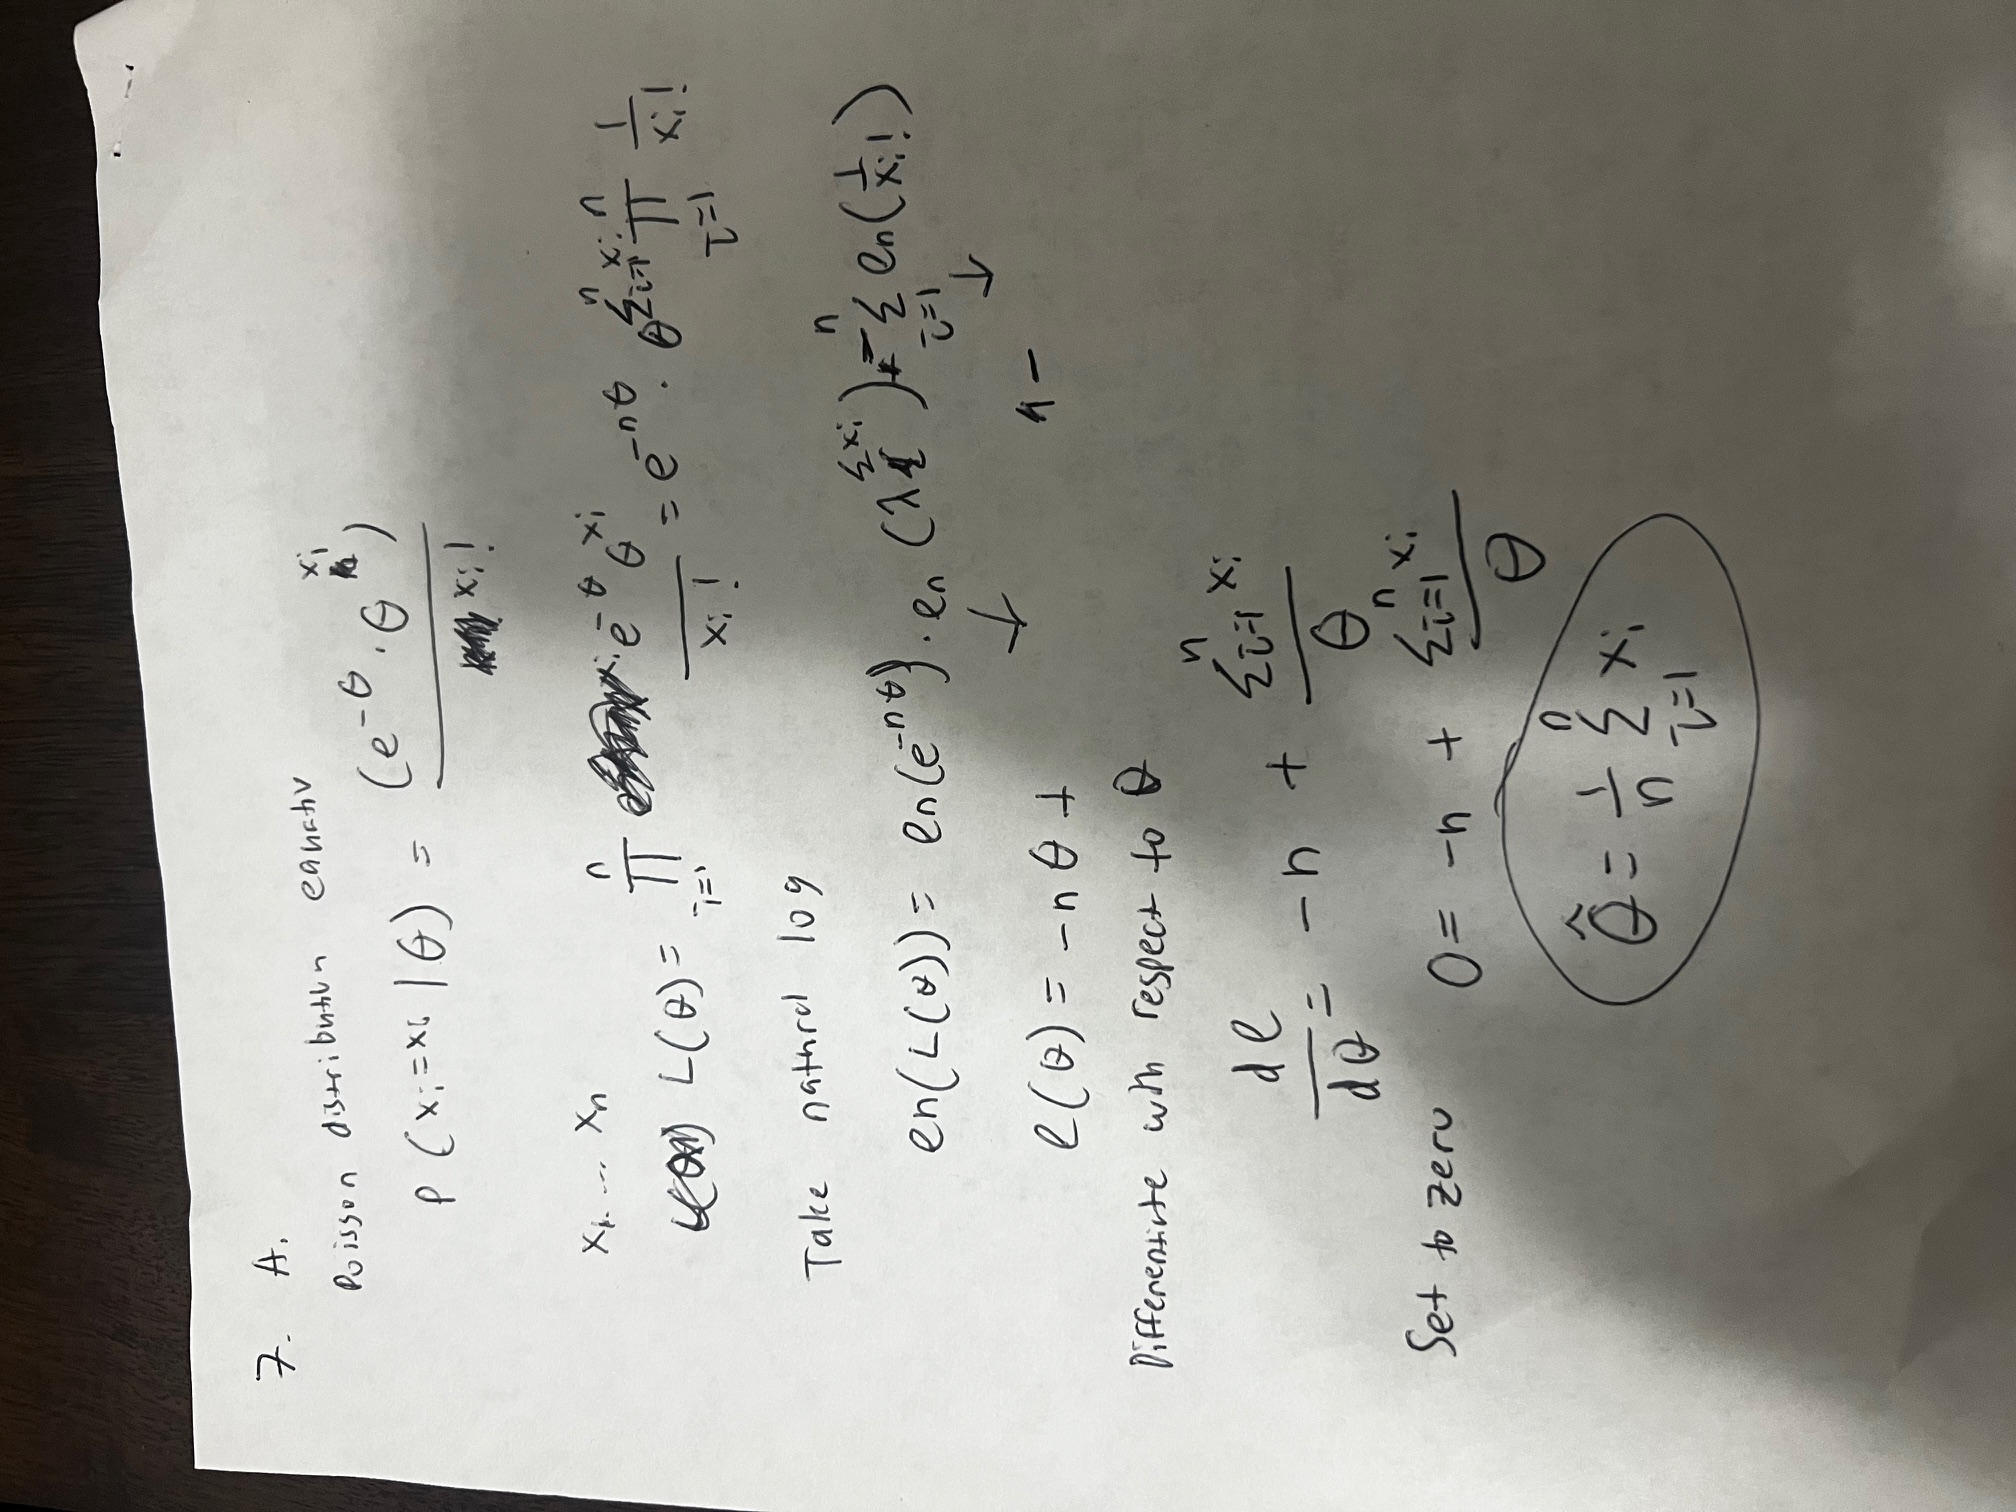

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

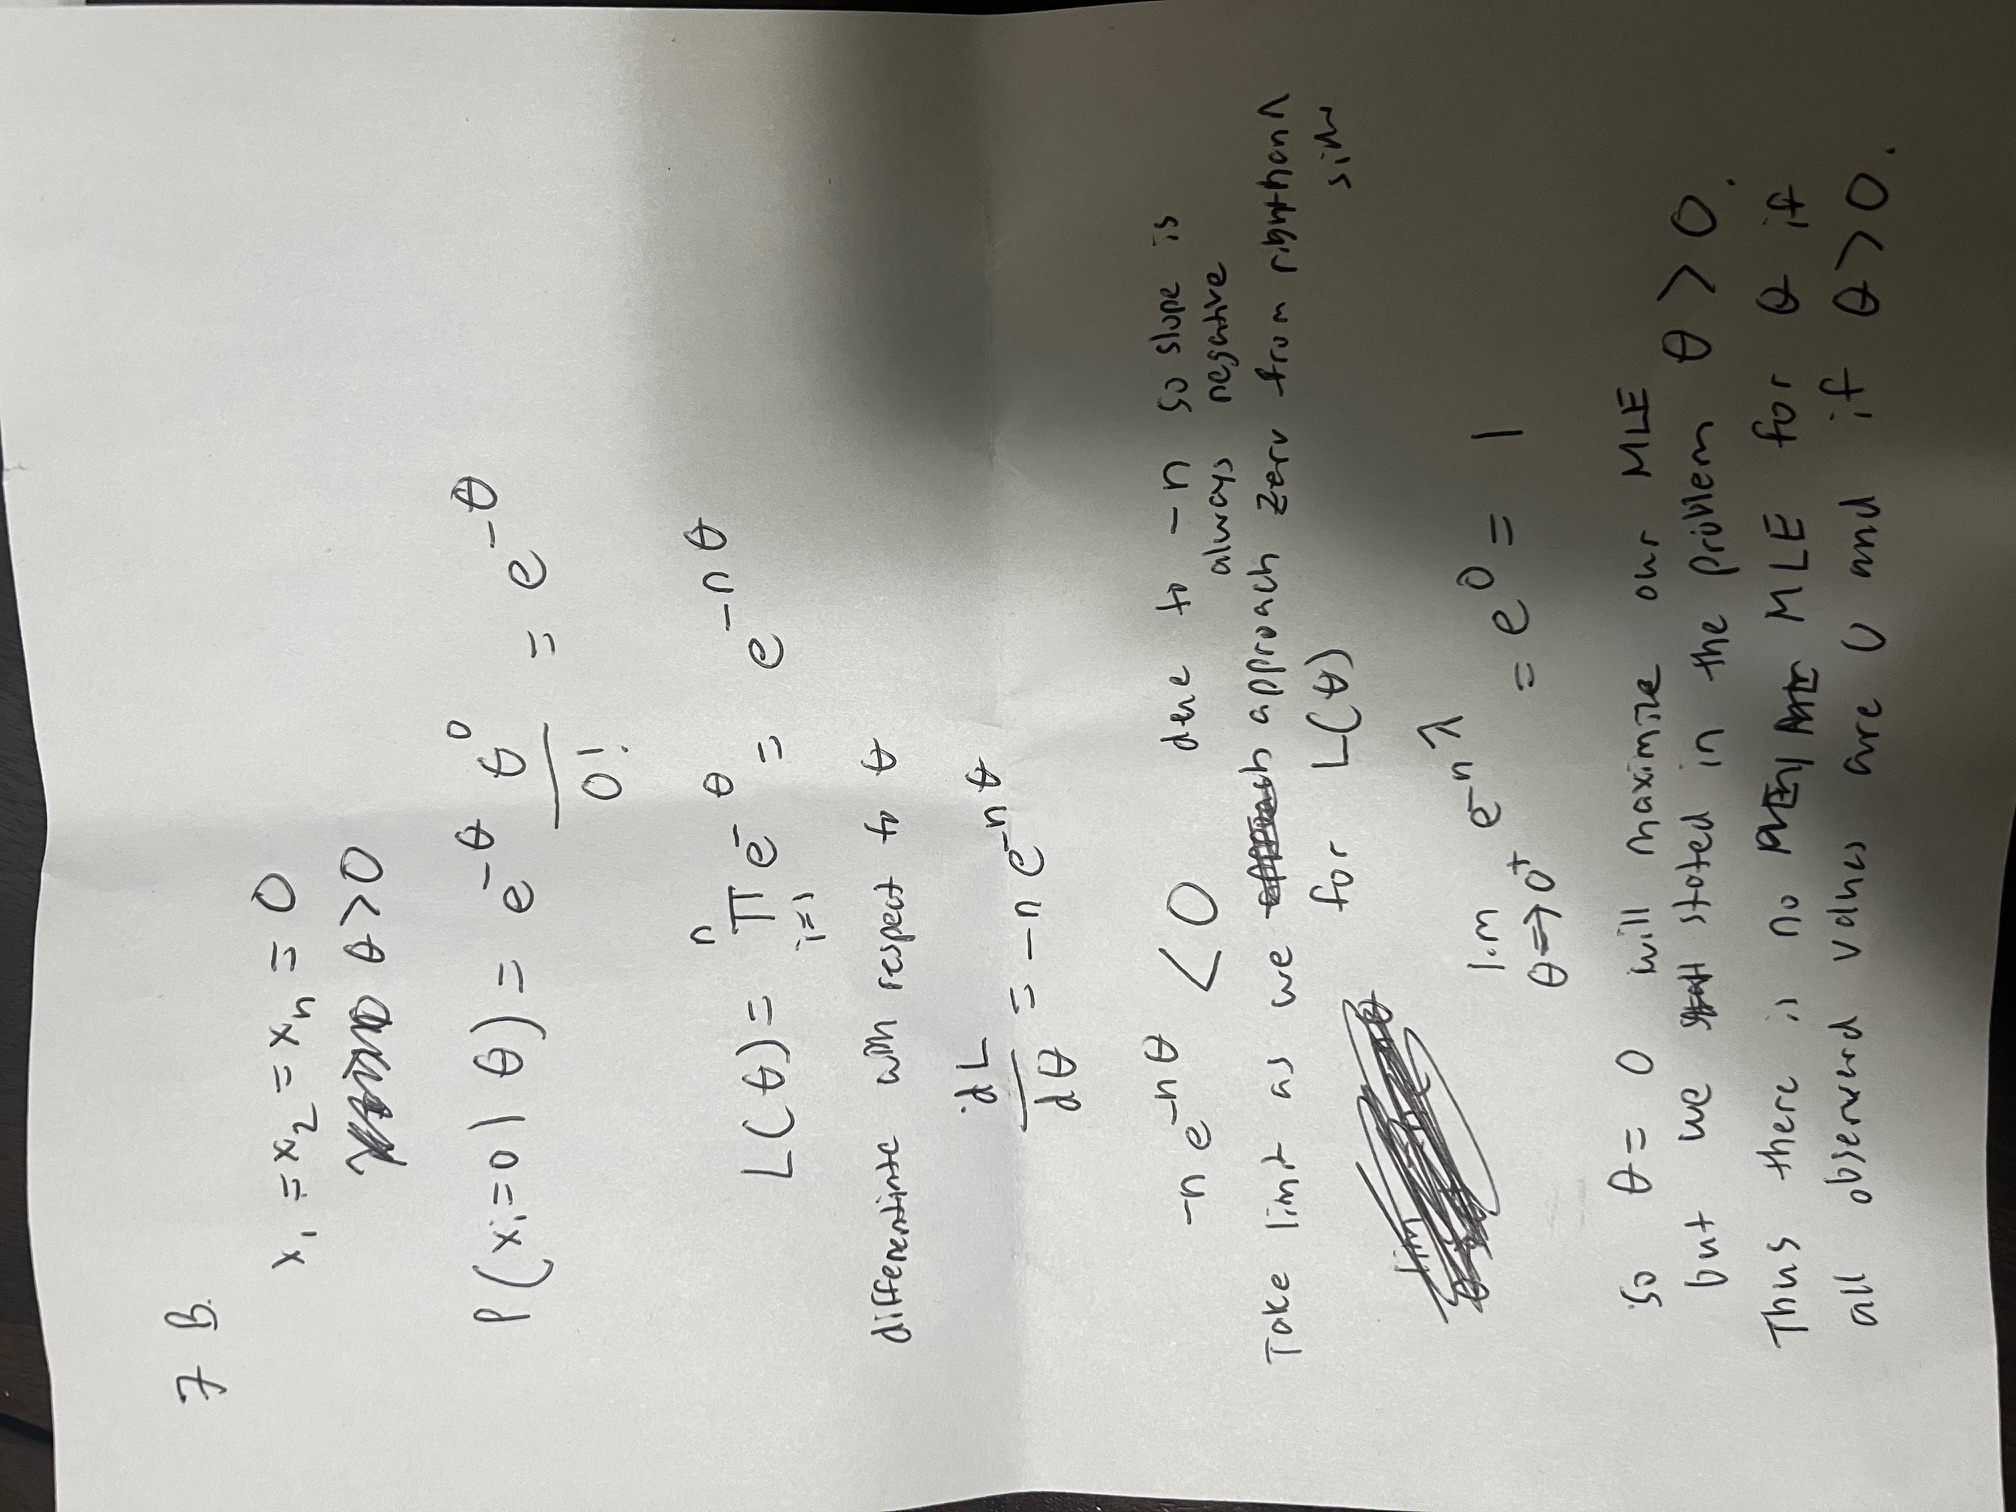

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

(a) Write a function to get all the songs of a particular artist.

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  